# Garbage Classification using Custom CNN

**This notebook builds and evaluates custom CNN models for classifying garbage images. The Garbage Classification Dataset contains 6 classifications: cardboard (393), glass (491), metal (400), paper(584), plastic (472) and trash(127)**

## Download Dataset from Kaggle


In [ ]:
import kagglehub

path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Dataset Path:", path)

100%|██████████| 82.0M/82.0M [00:00<00:00, 103MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2


## Import Libraries

In [ ]:
# Import Libraries

import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#For summary
!pip install torchsummary -q
from torchsummary import summary

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Seed
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

Using device: cuda


## Load and Explore Dataset

DATA_ROOT: /root/.cache/kagglehub/datasets/asdasdasasdas/garbage-classification/versions/2/Garbage classification/Garbage classification
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Total images: 2527
cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


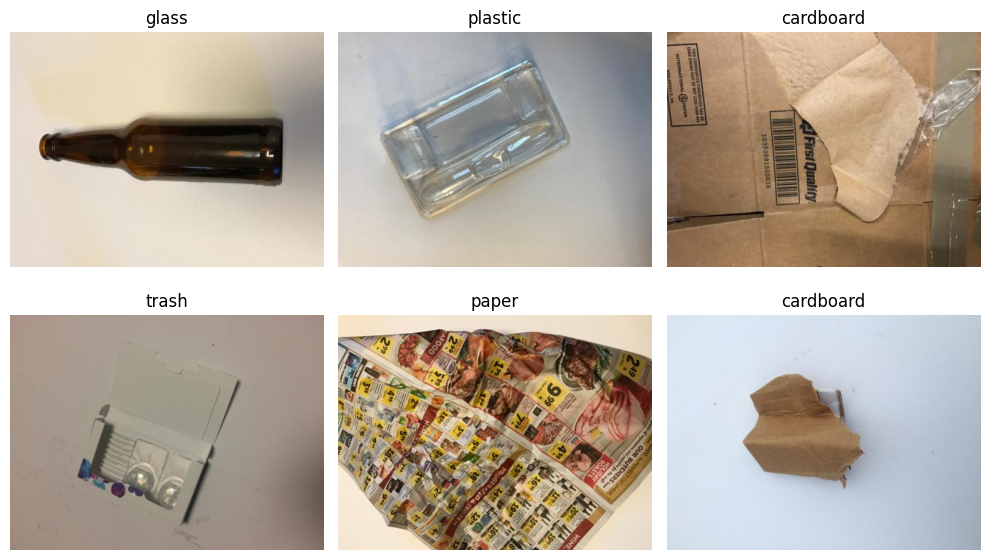

In [ ]:
# Set Correct Dataset Path and Explore
DATA_ROOT = os.path.join(path, "Garbage classification", "Garbage classification")
print("DATA_ROOT:", DATA_ROOT)

# Base dataset without transform for inspection
base_dataset = datasets.ImageFolder(root=DATA_ROOT)
class_names = base_dataset.classes
print("Classes:", class_names)
print("Total images:", len(base_dataset))

# Count images per class
for class_name in class_names:
    class_path = os.path.join(DATA_ROOT, class_name)
    image_count = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
    print(class_name, ":", image_count)

# Show random sample images
import random
plt.figure(figsize=(10, 6))
indices = random.sample(range(len(base_dataset)), 6)

for i, idx in enumerate(indices):
    image, label = base_dataset[idx]
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Preprocessing and Augmentation

Training data uses augmentation, while validation and test data use only resize and tensor conversion.

In [ ]:
# Transforms, Split, and DataLoaders

IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

total_size = len(base_dataset)
indices = torch.randperm(total_size, generator=torch.Generator().manual_seed(seed)).tolist()

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

# Separate datasets for train and test transforms
train_full = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
test_full = datasets.ImageFolder(root=DATA_ROOT, transform=test_transform)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(test_full, val_indices)
test_dataset = Subset(test_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

# Check one batch
images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Train size: 1768
Validation size: 379
Test size: 380
Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])


## Model Architecture

Two models are used: one is basic CNN and another one is CNN with Batch Normalization and Dropout for regularization.

In [ ]:
class CustomCNN_Basic(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN_Basic, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


class CustomCNN_BN_Dropout(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN_BN_Dropout, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


# Initialize Models
basic_model = CustomCNN_Basic(len(class_names)).to(device)
bn_dropout_model = CustomCNN_BN_Dropout(len(class_names)).to(device)

print("Basic CNN Summary")
summary(basic_model, (3, IMG_SIZE, IMG_SIZE), device="cuda" if torch.cuda.is_available() else "cpu")
print("\nCNN with BN + Dropout Summary")
summary(bn_dropout_model, (3, IMG_SIZE, IMG_SIZE), device="cuda" if torch.cuda.is_available() else "cpu")

Basic CNN Summary
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
            Conv2d-3           [-1, 64, 64, 64]          18,496
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5          [-1, 128, 32, 32]          73,856
         MaxPool2d-6          [-1, 128, 16, 16]               0
            Linear-7                  [-1, 128]       4,194,432
            Linear-8                    [-1, 6]             774
Total params: 4,288,454
Trainable params: 4,288,454
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forward/backward pass size (MB): 8.75
Params size (MB): 16.36
Estimated Total Size (MB): 25.30
----------------------------------------------------------------

CNN with BN + Dro

## Train & Validation

Adam optimizer, CrossEntropyLoss, and learning rate scheduling are used for both models.

In [ ]:
criterion = nn.CrossEntropyLoss()

basic_optimizer = torch.optim.Adam(basic_model.parameters(), lr=0.001)
bn_dropout_optimizer = torch.optim.Adam(bn_dropout_model.parameters(), lr=0.001)

basic_scheduler = torch.optim.lr_scheduler.StepLR(basic_optimizer, step_size=5, gamma=0.5)
bn_dropout_scheduler = torch.optim.lr_scheduler.StepLR(bn_dropout_optimizer, step_size=5, gamma=0.5)

EPOCHS = 10


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 50)

    return history, best_val_acc, best_weights

## Train Models

In [ ]:
print("Training Basic CNN...\n")
basic_history, basic_best_val_acc, basic_best_weights = train_model(
    basic_model, train_loader, val_loader,
    criterion, basic_optimizer, basic_scheduler,
    device, EPOCHS
)

print("\nTraining CNN with BN + Dropout...\n")
bn_dropout_history, bn_dropout_best_val_acc, bn_dropout_best_weights = train_model(
    bn_dropout_model, train_loader, val_loader,
    criterion, bn_dropout_optimizer, bn_dropout_scheduler,
    device, EPOCHS
)

print("Best Validation Accuracy of Basic CNN:", basic_best_val_acc)
print("Best Validation Accuracy of CNN with BN + Dropout:", bn_dropout_best_val_acc)

if bn_dropout_best_val_acc >= basic_best_val_acc:
    best_model_name = "CustomCNN_BN_Dropout"
    best_model = bn_dropout_model
    best_weights = bn_dropout_best_weights
else:
    best_model_name = "CustomCNN_Basic"
    best_model = basic_model
    best_weights = basic_best_weights

best_model.load_state_dict(best_weights)
torch.save(best_model.state_dict(), "garbage_best_model.pth")

print("Best model:", best_model_name)
print("Model weights saved as: garbage_best_model.pth")

Training Basic CNN...

Epoch 1/10
Train Loss: 1.5979 | Train Acc: 0.3128
Val Loss:   1.4420 | Val Acc:   0.4380
--------------------------------------------------
Epoch 2/10
Train Loss: 1.3703 | Train Acc: 0.4248
Val Loss:   1.3705 | Val Acc:   0.4195
--------------------------------------------------
Epoch 3/10
Train Loss: 1.2615 | Train Acc: 0.4830
Val Loss:   1.2183 | Val Acc:   0.5172
--------------------------------------------------
Epoch 4/10
Train Loss: 1.1545 | Train Acc: 0.5407
Val Loss:   1.2460 | Val Acc:   0.5303
--------------------------------------------------
Epoch 5/10
Train Loss: 1.0847 | Train Acc: 0.5848
Val Loss:   1.1775 | Val Acc:   0.5594
--------------------------------------------------
Epoch 6/10
Train Loss: 0.9680 | Train Acc: 0.6346
Val Loss:   1.0487 | Val Acc:   0.5910
--------------------------------------------------
Epoch 7/10
Train Loss: 0.9098 | Train Acc: 0.6691
Val Loss:   1.1310 | Val Acc:   0.5567
------------------------------------------------

## Visualizations and Test Evaluation

This section shows training curves, confusion matrix, test performance, and class-wise results.

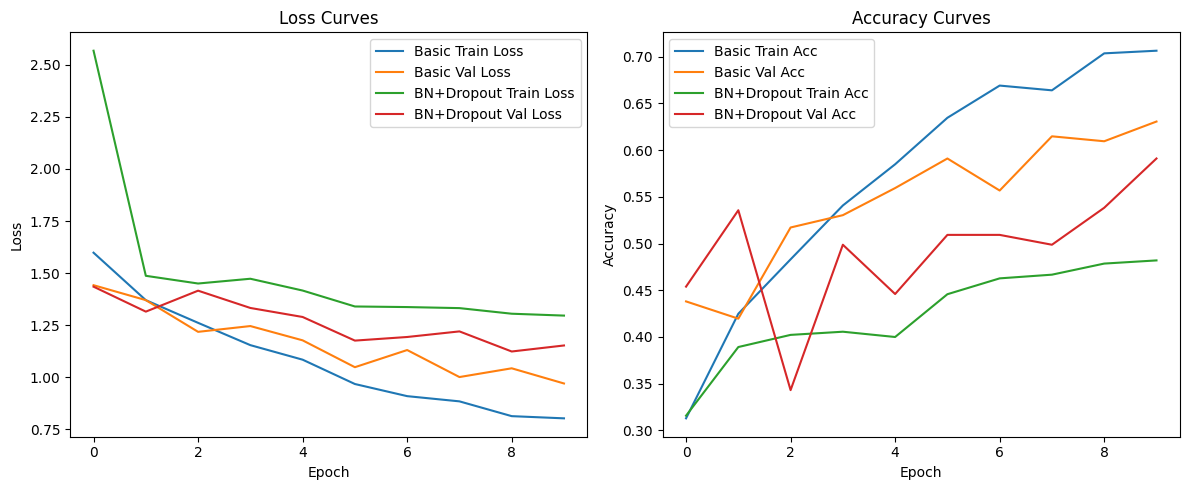

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.81      0.86      0.84        59
       glass       0.67      0.72      0.70        78
       metal       0.58      0.74      0.65        61
       paper       0.85      0.76      0.80        92
     plastic       0.64      0.55      0.59        66
       trash       0.68      0.54      0.60        24

    accuracy                           0.71       380
   macro avg       0.71      0.69      0.70       380
weighted avg       0.72      0.71      0.71       380



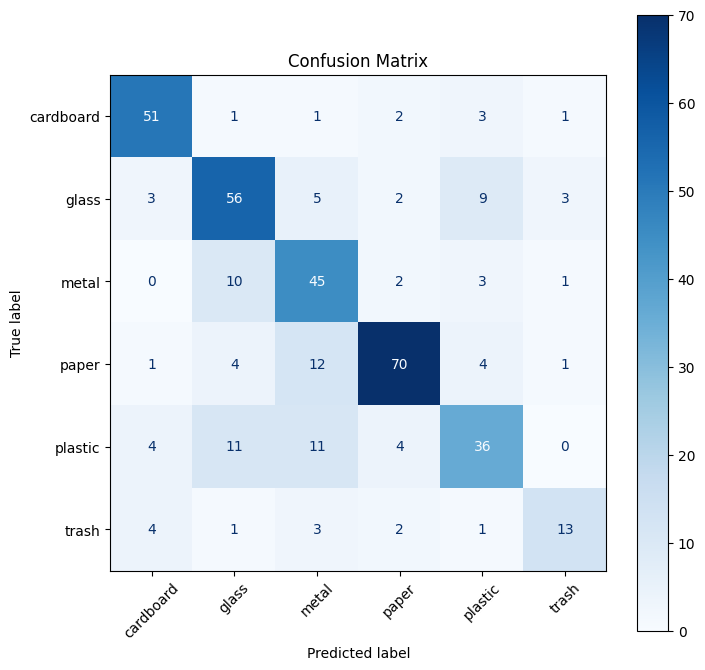

cardboard accuracy: 0.8644
glass accuracy: 0.7179
metal accuracy: 0.7377
paper accuracy: 0.7609
plastic accuracy: 0.5455
trash accuracy: 0.5417

Best performing class: cardboard
Worst performing class: trash


In [ ]:
# Plot Accuracy and Loss Curves

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(basic_history["train_loss"], label="Basic Train Loss")
plt.plot(basic_history["val_loss"], label="Basic Val Loss")
plt.plot(bn_dropout_history["train_loss"], label="BN+Dropout Train Loss")
plt.plot(bn_dropout_history["val_loss"], label="BN+Dropout Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(basic_history["train_acc"], label="Basic Train Acc")
plt.plot(basic_history["val_acc"], label="Basic Val Acc")
plt.plot(bn_dropout_history["train_acc"], label="BN+Dropout Train Acc")
plt.plot(bn_dropout_history["val_acc"], label="BN+Dropout Val Acc")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Evaluate Best Model on Test Set
best_model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# Per-class accuracy
class_correct = [0] * len(class_names)
class_total = [0] * len(class_names)

for t, p in zip(y_true, y_pred):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

class_accuracy = {}
for i, class_name in enumerate(class_names):
    acc = class_correct[i] / class_total[i]
    class_accuracy[class_name] = acc
    print(class_name, "accuracy:", round(acc, 4))

best_class = max(class_accuracy, key=class_accuracy.get)
worst_class = min(class_accuracy, key=class_accuracy.get)
print("\nBest performing class:", best_class)
print("Worst performing class:", worst_class)

## Sample Predictions

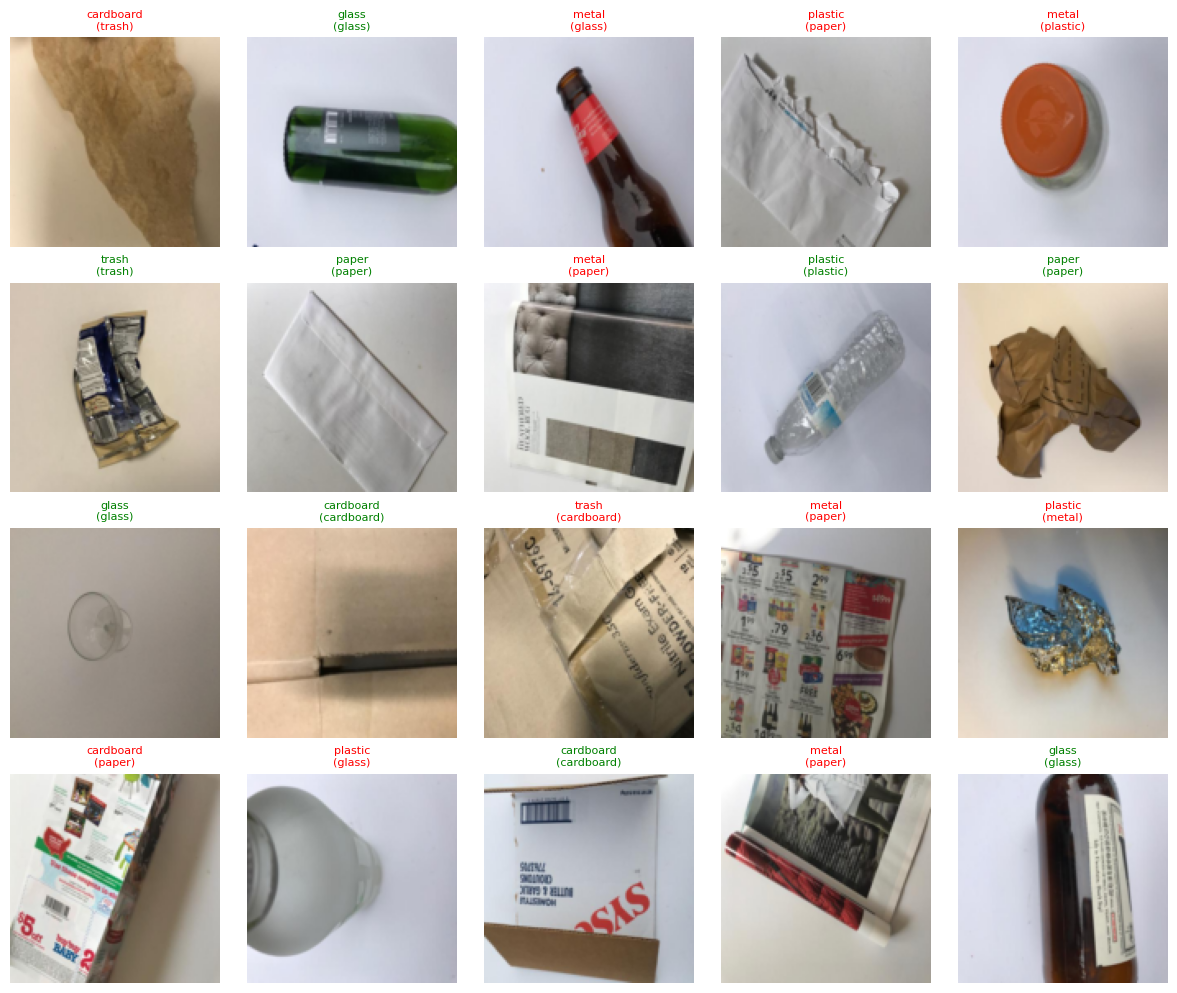

In [ ]:
# Show 20 Random Predictions from Test Set

import random

best_model.eval()

# Get random indices from test dataset
indices = random.sample(range(len(test_dataset)), 20)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(indices):
    image, label = test_dataset[idx]

    input_img = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = best_model(input_img)
        _, pred = torch.max(output, 1)

    pred_label = class_names[pred.item()]
    true_label = class_names[label]

    img = image.permute(1, 2, 0)

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)

    color = "green" if pred_label == true_label else "red"
    plt.title(f"{pred_label}\n({true_label})", color=color, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Analysis and Discussion**

The Basic CNN achieved the highest validation accuracy (0.6306), while the model with Batch Normalization and Dropout achieved 0.5910. So, the Basic Custom CNN performed better than CNN with BN + Dropout and basic custom CNN was selected as the final model.

From the confusion matrix:
- Cardboard performed best (0.8644)
- Trash performed worst (0.5417)
- Plastic also had lower accuracy (0.5455)

The model performs well on clear and consistent classes like cardboard and paper. However, it struggles with plastic and trash because these classes have more variation and often look similar to other categories like glass or metal.

Some confusion can be seen between:
- plastic and glass/metal  
- metal and glass  
- trash and multiple classes  

Overall, the model learns useful patterns, but performance drops for classes with similar visual features.

### **Conclusion and Future Work**

Here a custom CNN was developed to classify garbage images into six categories. Two models were tested, and the Basic Custom CNN achieved the best result with a validation accuracy of 0.6306. The final model was saved as `garbage_best_model.pth`.

Although the model performs well on some classes, it struggles with plastic and trash due to their visual similarity with other categories.

For future improvement:
- use more training data, especially for weak classes  
- apply stronger data augmentation  
- train for more epochs  
- try deeper models or transfer learning  